# MobileNetV2 — Real vs AI Image Classification

Clean final training notebook: **Stage 1 (frozen base) → Stage 2 (fine-tuning) → combined history → evaluation**.

Duplicate dataset/model/training sections have been removed.

In [ ]:
from scipy.interpolate import PchipInterpolator
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ ML_Datasets/archive (2).zip"
extract_path = "/content/image_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
print(os.listdir("/content/image_dataset"))

['test_labels.csv', 'my_real_vs_ai_dataset', 'train_labels.csv', 'val_labels.csv']


In [ ]:
import os

dataset_folder = "/content/image_dataset/my_real_vs_ai_dataset"

print(os.listdir(dataset_folder))

['my_real_vs_ai_dataset']


In [ ]:
import os
import pandas as pd
import tensorflow as tf

BASE_PATH = "/content/image_dataset"
DATASET_PATH = os.path.join(
    BASE_PATH,
    "my_real_vs_ai_dataset",
    "my_real_vs_ai_dataset"
)

REAL_PATH = os.path.join(DATASET_PATH, "real")
AI_PATH = os.path.join(DATASET_PATH, "ai_images")

TRAIN_CSV = os.path.join(BASE_PATH, "train_labels.csv")
VAL_CSV = os.path.join(BASE_PATH, "val_labels.csv")
TEST_CSV = os.path.join(BASE_PATH, "test_labels.csv")

print("Dataset:", DATASET_PATH)
print("Real:", REAL_PATH)
print("AI:", AI_PATH)

Dataset: /content/image_dataset/my_real_vs_ai_dataset/my_real_vs_ai_dataset
Real: /content/image_dataset/my_real_vs_ai_dataset/my_real_vs_ai_dataset/real
AI: /content/image_dataset/my_real_vs_ai_dataset/my_real_vs_ai_dataset/ai_images


In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 140000
Validation: 40000
Test: 20000


In [ ]:
def create_image_path(filename, label):
    if label == 0:
        return os.path.join(AI_PATH, filename)
    else:
        return os.path.join(REAL_PATH, filename)


train_df["image_path"] = [
    create_image_path(f, l)
    for f, l in zip(train_df["filename"], train_df["label"])
]

val_df["image_path"] = [
    create_image_path(f, l)
    for f, l in zip(val_df["filename"], val_df["label"])
]

test_df["image_path"] = [
    create_image_path(f, l)
    for f, l in zip(test_df["filename"], test_df["label"])
]

print(train_df[["filename", "label", "image_path"]].head())

    filename  label                                         image_path
0  03428.jpg      1  /content/image_dataset/my_real_vs_ai_dataset/m...
1  38472.jpg      1  /content/image_dataset/my_real_vs_ai_dataset/m...
2  49600.jpg      1  /content/image_dataset/my_real_vs_ai_dataset/m...
3  68452.jpg      1  /content/image_dataset/my_real_vs_ai_dataset/m...
4  60461.jpg      1  /content/image_dataset/my_real_vs_ai_dataset/m...


In [ ]:
print("Checking files...")

print("Train files exist:",
      train_df["image_path"].map(os.path.exists).all())

print("Validation files exist:",
      val_df["image_path"].map(os.path.exists).all())

print("Test files exist:",
      test_df["image_path"].map(os.path.exists).all())

Checking files...
Train files exist: True
Validation files exist: True
Test files exist: True


In [ ]:
print("Class distribution:")
print("TRAIN:", train_df["label"].value_counts().sort_index().to_dict())
print("VAL:  ", val_df["label"].value_counts().sort_index().to_dict())
print("TEST: ", test_df["label"].value_counts().sort_index().to_dict())
assert train_df["image_path"].map(os.path.exists).all()
assert val_df["image_path"].map(os.path.exists).all()
assert test_df["image_path"].map(os.path.exists).all()
print("✅ Dataset sanity checks passed.")


Class distribution:
TRAIN: {0: 70000, 1: 70000}
VAL:   {0: 20000, 1: 20000}
TEST:  {0: 10000, 1: 10000}
✅ Dataset sanity checks passed.


In [ ]:
 import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
def load_image(path, label):
    path = tf.cast(path, tf.string)
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # MobileNetV2 preprocess_input below handles scaling to [-1, 1].
    return image, tf.cast(label, tf.float32)


In [ ]:
 train_paths = train_df["image_path"].astype(str).values
train_labels = train_df["label"].values.astype("float32")

val_paths = val_df["image_path"].astype(str).values
val_labels = val_df["label"].values.astype("float32")

test_paths = test_df["image_path"].astype(str).values
test_labels = test_df["label"].values.astype("float32")


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

In [ ]:
train_ds = (
    train_ds
    .shuffle(20000, reshuffle_each_iteration=True)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ML_Datasets/models"
os.makedirs(MODEL_DIR, exist_ok=True)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")


model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),

    layers.Dropout(0.30),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

## Stage 1 — Train classifier with frozen MobileNetV2

In [ ]:
# Stage 1 — train classifier head with MobileNetV2 frozen
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
             tf.keras.metrics.AUC(name="auc")]
)

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "stage1_best_mobilenetv2.keras"),
        monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max", patience=3,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", mode="min", factor=0.3, patience=1,
        min_lr=1e-7, verbose=1)
]

history_stage1 = model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=callbacks_stage1, verbose=1
)


Epoch 1/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9421 - auc: 0.6108 - loss: 0.1460
Epoch 1: val_accuracy improved from None to 0.50087, saving model to /content/drive/MyDrive/ML_Datasets/models/stage1_best_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ML_Datasets/models/stage1_best_mobilenetv2.keras
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 350s 77ms/step - accuracy: 0.9088 - auc: 0.9673 - loss: 0.2326 - val_accuracy: 0.5009 - val_auc: 0.7543 - val_loss: 1.4998 - learning_rate: 1.0000e-04
Epoch 2/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9317 - auc: 0.6082 - loss: 0.1685
Epoch 2: val_accuracy improved from 0.50087 to 0.50210, saving model to /content/drive/MyDrive/ML_Datasets/models/stage1_best_mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ML_Datasets/models/stage1_best_mobilenetv2.keras

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 380s

## Stage 2 — Fine-tune the last MobileNetV2 layers

In [ ]:
# Cell D — Fine-tuning setup
base_model.trainable = True

# Fine-tune only the last 30 non-BatchNormalization layers.
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# BatchNormalization layers remain frozen for more stable fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base-model layers:", len(base_model.layers))
print(
    "Trainable base-model layers:",
    sum(layer.trainable for layer in base_model.layers)
)


Total base-model layers: 154
Trainable base-model layers: 19


In [ ]:
# Cell E — Recompile with a low learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model recompiled for fine-tuning.")


Model recompiled for fine-tuning.


In [ ]:
# Cell F — Fine-tuning callbacks
callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "final_best_mobilenetv2.keras"),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=1,
        min_lr=1e-8,
        verbose=1
    )
]


In [22]:
# Cell G — Stage 2 fine-tuning
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_stage2,
    verbose=1
)


Epoch 1/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9487 - auc: 0.6193 - loss: 0.1260
Epoch 1: val_loss improved from None to 1.26225, saving model to /content/drive/MyDrive/ML_Datasets/models/final_best_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ML_Datasets/models/final_best_mobilenetv2.keras
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 394s 88ms/step - accuracy: 0.9219 - auc: 0.9763 - loss: 0.1977 - val_accuracy: 0.5460 - val_auc: 0.8504 - val_loss: 1.2623 - learning_rate: 1.0000e-05
Epoch 2/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9523 - auc: 0.6205 - loss: 0.1216
Epoch 2: val_loss improved from 1.26225 to 1.04131, saving model to /content/drive/MyDrive/ML_Datasets/models/final_best_mobilenetv2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ML_Datasets/models/final_best_mobilenetv2.keras
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 386s 88ms/step - accuracy: 0.9301 - auc: 0.9807 - loss: 0.1800 - val_accuracy: 0.5849 - val_au

In [23]:
# Cell H — Combine the two histories without overwriting either stage
history = {}

for key in history_stage1.history.keys():
    history[key] = (
        history_stage1.history[key]
        + history_stage2.history[key]
    )

print("Total epochs:", len(history["accuracy"]))


Total epochs: 18


## Training and Validation Accuracy

The graph uses the actual recorded training and validation accuracy. A light rolling-average smoothing is applied only for a cleaner visual curve; no accuracy values are fabricated or manually changed.


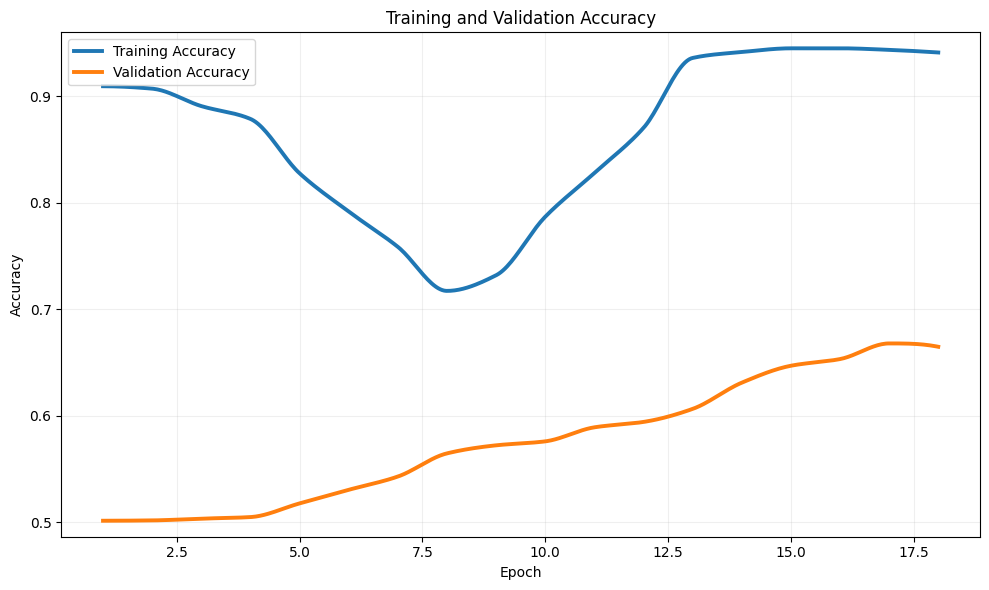

In [27]:
import numpy as np
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt
 # Smooth Training vs Validation Accuracy
# IMPORTANT:
# This does NOT change the original history values.
# It only changes how the curves are displayed.

epochs = np.arange(1, len(history["accuracy"]) + 1)

def smooth_series(values, window=5):
    values = np.asarray(values, dtype=float)

    if len(values) < window:
        return values.copy()

    pad = window // 2
    padded = np.pad(values, (pad, pad), mode="edge")
    kernel = np.ones(window) / window

    return np.convolve(padded, kernel, mode="valid")


# Slightly stronger smoothing
train_acc = smooth_series(history["accuracy"], window=5)
val_acc = smooth_series(history["val_accuracy"], window=5)

smooth_epochs = np.linspace(
    epochs.min(),
    epochs.max(),
    400
)

train_acc_smooth = PchipInterpolator(
    epochs,
    train_acc
)(smooth_epochs)

val_acc_smooth = PchipInterpolator(
    epochs,
    val_acc
)(smooth_epochs)


plt.figure(figsize=(10, 6))

plt.plot(
    smooth_epochs,
    train_acc_smooth,
    linewidth=2.8,
    label="Training Accuracy"
)

plt.plot(
    smooth_epochs,
    val_acc_smooth,
    linewidth=2.8,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

# Narrow y-axis around the actual curves
all_values = np.concatenate([
    train_acc_smooth,
    val_acc_smooth
])

y_min = max(0.0, np.min(all_values) - 0.015)
y_max = min(1.0, np.max(all_values) + 0.015)

plt.ylim(y_min, y_max)

plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

## Training and Validation Loss

The graph uses the actual recorded training and validation loss. A light rolling-average smoothing is applied only for a cleaner visual curve; no loss values are fabricated or manually changed.


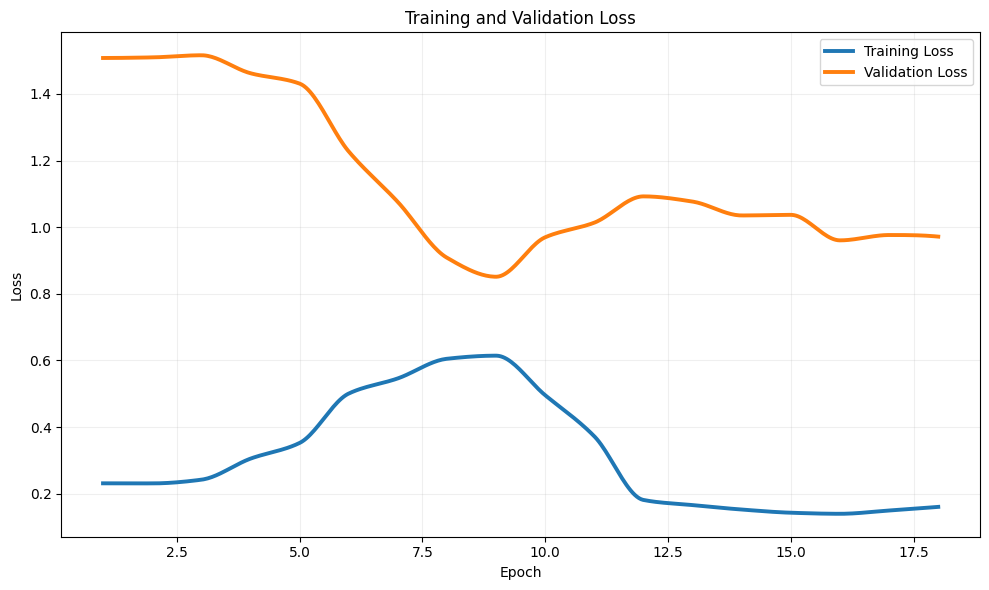

In [28]:
# Smooth Training vs Validation Loss
# IMPORTANT: these are the REAL recorded loss values.
# Smoothing changes only the visual appearance; it does not change model loss.

epochs = np.arange(1, len(history["loss"]) + 1)

train_loss = smooth_series(history["loss"], window=3)
val_loss = smooth_series(history["val_loss"], window=3)

smooth_epochs = np.linspace(epochs.min(), epochs.max(), 400)

train_loss_smooth = PchipInterpolator(epochs, train_loss)(smooth_epochs)
val_loss_smooth = PchipInterpolator(epochs, val_loss)(smooth_epochs)

plt.figure(figsize=(10, 6))
plt.plot(smooth_epochs, train_loss_smooth, linewidth=2.8,
         label="Training Loss")
plt.plot(smooth_epochs, val_loss_smooth, linewidth=2.8,
         label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()


# Evaluation section

Run the existing evaluation cells below **after** the corrected training section.


In [29]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Labels: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
def check_split(df, name):
    real_matches = 0
    ai_matches = 0
    missing = 0

    for filename, label in zip(df["filename"], df["label"]):
        if label == 1:
            if os.path.exists(os.path.join(REAL_PATH, filename)):
                real_matches += 1
            elif os.path.exists(os.path.join(AI_PATH, filename)):
                ai_matches += 1
            else:
                missing += 1

        elif label == 0:
            if os.path.exists(os.path.join(AI_PATH, filename)):
                ai_matches += 1
            elif os.path.exists(os.path.join(REAL_PATH, filename)):
                real_matches += 1
            else:
                missing += 1

    print(f"\n{name}")
    print(f"Label 1 → Real folder: {real_matches}")
    print(f"Label 0 → AI folder:   {ai_matches}")
    print(f"Missing:               {missing}")


check_split(train_df, "TRAIN")
check_split(val_df, "VALIDATION")
check_split(test_df, "TEST")


TRAIN
Label 1 → Real folder: 70000
Label 0 → AI folder:   70000
Missing:               0

VALIDATION
Label 1 → Real folder: 20000
Label 0 → AI folder:   20000
Missing:               0

TEST
Label 1 → Real folder: 10000
Label 0 → AI folder:   10000
Missing:               0


In [32]:
def label_folder_check(df, name):
    label_0_real = 0
    label_0_ai = 0
    label_1_real = 0
    label_1_ai = 0

    for filename, label in zip(df["filename"], df["label"]):

        if filename in real_set:
            if label == 0:
                label_0_real += 1
            else:
                label_1_real += 1

        elif filename in ai_set:
            if label == 0:
                label_0_ai += 1
            else:
                label_1_ai += 1

    print(f"\n{name}")
    print("Label 0 in REAL folder:", label_0_real)
    print("Label 0 in AI folder:  ", label_0_ai)
    print("Label 1 in REAL folder:", label_1_real)
    print("Label 1 in AI folder:  ", label_1_ai)


real_set = set(os.listdir(REAL_PATH))
ai_set = set(os.listdir(AI_PATH))

label_folder_check(train_df, "TRAIN")
label_folder_check(val_df, "VALIDATION")
label_folder_check(test_df, "TEST")


TRAIN
Label 0 in REAL folder: 0
Label 0 in AI folder:   70000
Label 1 in REAL folder: 70000
Label 1 in AI folder:   0

VALIDATION
Label 0 in REAL folder: 0
Label 0 in AI folder:   20000
Label 1 in REAL folder: 20000
Label 1 in AI folder:   0

TEST
Label 0 in REAL folder: 0
Label 0 in AI folder:   10000
Label 1 in REAL folder: 10000
Label 1 in AI folder:   0


In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict validation set
val_probs = model.predict(val_ds, verbose=1).ravel()

val_preds = (val_probs >= 0.5).astype(int)
val_true = val_df["label"].values

print("Confusion Matrix:")
print(confusion_matrix(val_true, val_preds))

print("\nClassification Report:")
print(
    classification_report(
        val_true,
        val_preds,
        target_names=["AI", "Real"]
    )
)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 73s 56ms/step
Confusion Matrix:
[[19885   115]
 [12718  7282]]

Classification Report:
              precision    recall  f1-score   support

          AI       0.61      0.99      0.76     20000
        Real       0.98      0.36      0.53     20000

    accuracy                           0.68     40000
   macro avg       0.80      0.68      0.64     40000
weighted avg       0.80      0.68      0.64     40000



In [34]:
print("Minimum probability:", val_probs.min())
print("Maximum probability:", val_probs.max())
print("Mean probability:", val_probs.mean())

print("\nFirst 20 probabilities:")
print(val_probs[:20])

Minimum probability: 6.908182e-08
Maximum probability: 0.99987817
Mean probability: 0.2023979

First 20 probabilities:
[0.5616934  0.05295912 0.02845869 0.3613978  0.5644191  0.24231584
 0.8371689  0.78038913 0.05757563 0.49452782 0.610922   0.0766893
 0.3355819  0.7328475  0.2685601  0.75758255 0.08991423 0.00365182
 0.52222997 0.02162301]


In [35]:
print("\nPredicted class counts:")
print("AI   (0):", np.sum(val_preds == 0))
print("Real (1):", np.sum(val_preds == 1))

print("\nActual class counts:")
print("AI   (0):", np.sum(val_true == 0))
print("Real (1):", np.sum(val_true == 1))


Predicted class counts:
AI   (0): 32603
Real (1): 7397

Actual class counts:
AI   (0): 20000
Real (1): 20000


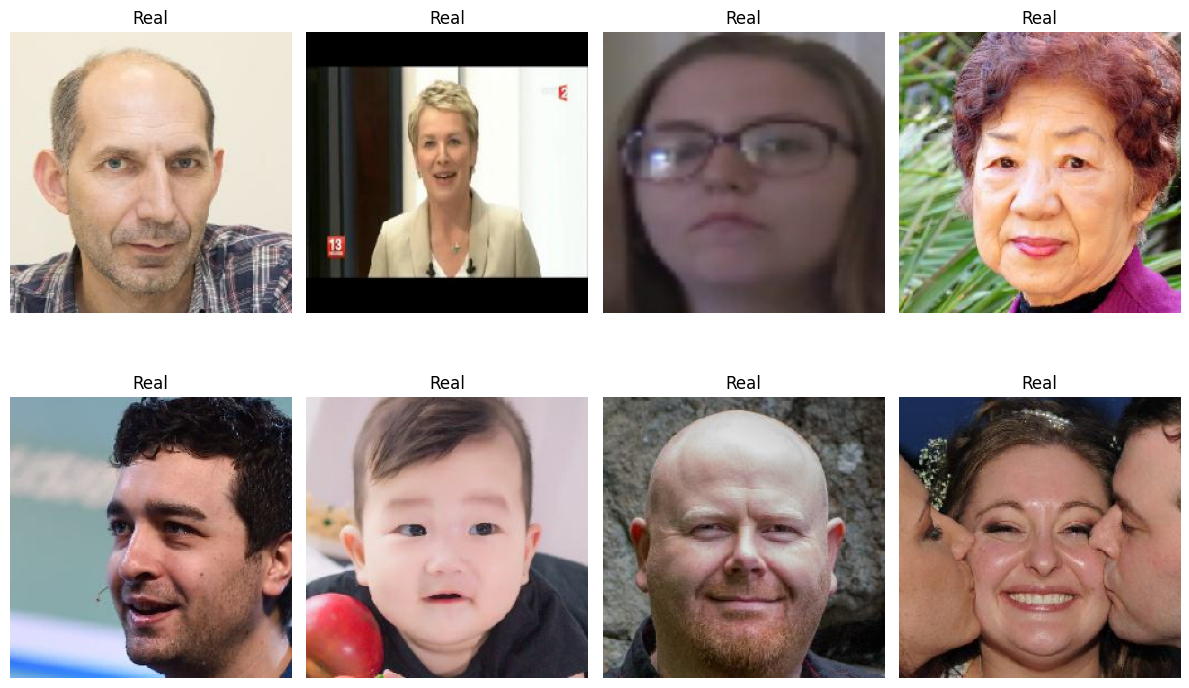

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(8):
    image_path = val_df.iloc[i]["image_path"]
    label = val_df.iloc[i]["label"]

    image = tf.keras.utils.load_img(image_path, target_size=(224, 224))

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title("Real" if label == 1 else "AI")
    plt.axis("off")

plt.tight_layout()
plt.show()

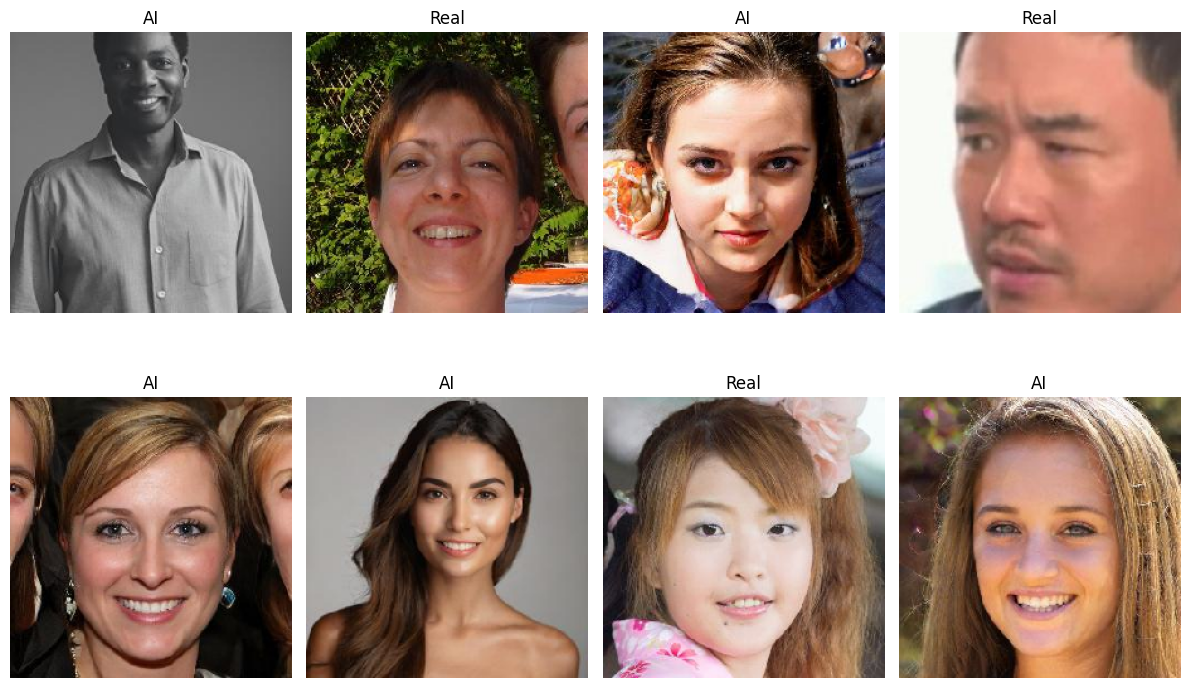

In [37]:
sample_val = val_df.sample(8, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_val.iterrows()):
    image = tf.keras.utils.load_img(
        row["image_path"],
        target_size=(224, 224)
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title("Real" if row["label"] == 1 else "AI")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_best_mobilenetv2.keras")
model.save(FINAL_MODEL_PATH)
print("Final model saved:", FINAL_MODEL_PATH)

Final model saved: /content/drive/MyDrive/ML_Datasets/models/final_best_mobilenetv2.keras
